# FIP 02 — NE-only events: NE and DA transient dissociation

`fip_00_explore.ipynb`'s "NE"-only-onsets-aligned-to-movement figure (formerly in
`fip_01_movement_value_coding.ipynb`, removed there) treated every PL-GCaMP ("NE") onset the
same way. This notebook asks a sharper question: **which NE transients happen without a
concurrent DA transient**, versus NE transients where DA also surges — and whether movement
(motion energy, ME) looks different around those two kinds of NE event.

**"NE"**: this dataset's curation has no norepinephrine (nLight) sensor; per-project convention
the PL-GCaMP channel stands in for NE. **"DA"**: NAc dLight.

**Classification**: for each NE onset, detect DA onsets independently with the same
`threshold_onsets()` used throughout this notebook family; an NE onset is **NE+DA** if a DA
onset falls within ±0.5 s of it, otherwise **NE-only**. Four analyses characterize the
relationship beyond that binary split (DA peak distribution, a shuffle control for the
coincidence rate, onset-lag distribution, and peak-amplitude correlation) before the main
figure (ME aligned to each group). See the implementation plan
(`fip_02_ne_only_events` plan, 2026-09-14) for the full design rationale.

Setup cells below are copied from `fip_01_movement_value_coding.ipynb` (itself copied from
`fip_00_explore.ipynb`) rather than factored into a shared module — a 3rd notebook duplicating
this setup strengthens the case for the `fip_utils.py` extraction already logged in
`fip_todo.md`.

## Imports & setup

In [72]:
import os
import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import fastparquet  # noqa: F401  # load_nwb_list uses pd.read_parquet(engine="fastparquet")

# Rachel's lab utilities (installed / mounted in the Code Ocean capsule).
from rachel_analysis_utils import nwb_utils as r_utils

# AIND event-alignment primitive (peri-event windowing) and zscore_fip (the same z-scoring
# Rachel's pipeline uses -- see fip_01_movement_value_coding.ipynb for the full trace).
from aind_dynamic_foraging_data_utils import alignment, enrich_dfs

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)

## Data loading

In [73]:
# Same asset as fip_00_explore.ipynb / fip_01_movement_value_coding.ipynb.
plot_loc = "/root/capsule/data/DA_NE_4channels/"

assert os.path.isdir(plot_loc), (
    f"{plot_loc} not found. Attach asset 6babbf3d-6970-4456-aab5-d730ed57c269 "
    "(saved parquet hierarchy) to this capsule, or fix the path."
)
print("plot_loc =", plot_loc)

plot_loc = /root/capsule/data/DA_NE_4channels/


In [74]:
# load_nwb_list returns df_bg (background-coefficient csvs) as a 4th value; unused here
# (same as df_sess/df_slope) but must be unpacked.
nwb_list_raw, df_sess, df_slope, df_bg = r_utils.load_nwb_list(plot_loc, load_fip=True)
print(f"Loaded {len(nwb_list_raw)} session(s)")

loading 7 df_sess file(s)
no bg_coef files found at plot location, skipping
no rpe_slope.csv found at plot location, skipping
loading 808054_2025-09-02
loading 808054_2025-09-03
loading 808054_2025-09-04
loading 808054_2025-09-05
loading 808054_2025-09-08
loading 808054_2025-09-09
loading 808054_2025-09-10
loading 808054_2025-09-11
loading 808054_2025-09-12
loading 808054_2025-09-15
loading 808054_2025-09-16
loading 808054_2025-09-17
loading 808054_2025-09-18
loading 808054_2025-09-19
loading 808054_2025-09-22
loading 808054_2025-09-23
loading 808054_2025-09-24
loading 808054_2025-09-25
loading 808054_2025-09-26
loading 808054_2025-10-02
loading 808054_2025-10-07
loading 808054_2025-10-08
loading 808054_2025-10-10
loading 808054_2025-10-13
loading 808054_2025-10-14
loading 808054_2025-10-15
loading 808054_2025-10-16
loading 808054_2025-10-17
loading 808056_2025-09-12
loading 808056_2025-09-15
loading 808056_2025-09-16
loading 808056_2025-09-17
loading 808056_2025-09-18
loading 808056_2

### Curation

Same as `fip_00_explore.ipynb`/`fip_01_movement_value_coding.ipynb`, including the patch for
`data_curation_helpers.apply_curation_nwb_list`'s missing private-helper imports, and
`drop_borderline=False` + freeing `nwb_list_raw` right after (curation-step memory fix).

In [75]:
USE_CURATION = True
CURATION_FILE = "DA_NE_4channel_datacuration_firstpass"

# apply_curation_nwb_list lives in data_curation_helpers, not nwb_utils.
from rachel_analysis_utils import data_curation_helpers as r_curation

# Upstream bug: data_curation_helpers.apply_curation_nwb_list calls private helpers that it
# never imports -- they live in nwb_utils and work fine there, so patch them in. Gated so this
# becomes a no-op once the helpers are imported upstream.
for _helper in ("_parse_session_id", "_actual_map_for_session", "_get_df_trials_col_mapping",
                "_map_event_to_intended_measurement", "_apply_channel_drops_to_nwb"):
    if not hasattr(r_curation, _helper):
        setattr(r_curation, _helper, getattr(r_utils, _helper))

json_path = None
try:
    import rachel_analysis_utils
    pkg_dir = os.path.dirname(rachel_analysis_utils.__file__)
    cand = os.path.join(pkg_dir, "data_curation", CURATION_FILE + ".json")
    if os.path.exists(cand):
        json_path = cand
except Exception:
    pass
if json_path is None:
    hits = glob.glob("/src/**/data_curation/" + CURATION_FILE + ".json", recursive=True)
    assert hits, "Could not locate " + CURATION_FILE + ".json"
    json_path = hits[0]

with open(json_path, "r") as fh:
    df_curation = json.load(fh)
print("Using curation:", json_path)

# drop_borderline only controls whether a SECOND list (curated_with_borderline) gets built --
# nwb_list itself is identical either way. That second list is never used here, but
# apply_curation_nwb_list still deep-copies + processes every session to build it when True,
# doubling memory for nothing. False skips that pass entirely.
nwb_list, _nwb_list_curated_unused = r_curation.apply_curation_nwb_list(
    nwb_list_raw, df_curation, drop_borderline=False
)
print(f"Curated -> {len(nwb_list)} session(s) kept.")

# nwb_list_raw is a full second copy of the pre-curation dataset and isn't referenced again
# below -- free it now instead of letting it sit in RAM for the rest of the kernel.
del nwb_list_raw, _nwb_list_curated_unused
import gc
gc.collect()

Using curation: /src/rachel-analysis-utils/src/rachel_analysis_utils/data_curation/DA_NE_4channel_datacuration_firstpass.json
Curated -> 172 session(s) kept.


0

## Data processing

### Select a session

In [76]:
SESSION_IDX = 0
nwb = nwb_list[SESSION_IDX]
df_fip = nwb.df_fip
assert (df_fip.groupby("event")["timestamps"].diff().dropna() >= 0).all(), \
    "df_fip timestamps not sorted within an event — sort before use"
df_trials = getattr(nwb, "df_trials", None)

ALIGN_COL = "goCue_start_time_in_session"
assert df_trials is not None and ALIGN_COL in df_trials.columns, (
    f"Need '{ALIGN_COL}' on df_trials (first-go-cue-zeroed clock). Available: "
    f"{None if df_trials is None else list(df_trials.columns)}")

print("session_id:", nwb.session_id, "| df_fip", df_fip.shape, "| trials", df_trials.shape)

session_id: 808054_2025-09-02 | df_fip (629134, 11) | trials (524, 113)


In [77]:
def parse_event(name):
    """'G_1_dff-poly' -> ('G','1','dff-poly'); 'R_0' -> ('R','0','raw')."""
    parts = name.split("_")
    channel = parts[0]
    fiber = parts[1] if len(parts) > 1 else "?"
    variant = "_".join(parts[2:]) if len(parts) > 2 else "raw"
    return channel, fiber, variant


def get_trace(df_fip, event_name, data_col="data"):
    """(t, y) arrays for one df_fip series (asserted time-sorted per event)."""
    sub = df_fip[df_fip["event"] == event_name]
    return sub["timestamps"].to_numpy(), sub[data_col].to_numpy()


events = [e for e in sorted(df_fip["event"].unique()) if "pearson" not in e.lower()]
meta = pd.DataFrame([(e,) + parse_event(e) for e in events],
                    columns=["event", "channel", "fiber", "variant"])
if "intended_measurement" in df_fip.columns:
    ev2region = (df_fip.dropna(subset=["intended_measurement"])
                 .groupby("event")["intended_measurement"]
                 .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None))
    meta["region"] = meta["event"].map(ev2region)
print(f"{len(events)} FIP series (pearsonR excluded)")
meta

5 FIP series (pearsonR excluded)


,event,channel,fiber,variant,region
0,G_0_dff-bright_mc-iso-IRLS,G,0,dff-bright_mc-iso-IRLS,NAc(L)-dLight
1,G_2_dff-bright_mc-iso-IRLS,G,2,dff-bright_mc-iso-IRLS,PL(R)-Gcamp
2,G_3_dff-bright_mc-iso-IRLS,G,3,dff-bright_mc-iso-IRLS,NAc(R)-dLight
3,R_2_dff-bright_mc-iso-IRLS,R,2,dff-bright_mc-iso-IRLS,NAc(R)-rAch
4,R_3_dff-bright_mc-iso-IRLS,R,3,dff-bright_mc-iso-IRLS,NAc(L)-rAch


### NE and DA example channels

Same `pick_example` selection logic used throughout this notebook family (prefers a `dff`
variant, then most finite samples) -- here picking one representative NE (PL-GCaMP) channel and
one representative DA (NAc dLight) channel for this session.

In [78]:
def pick_example(meta, df_fip, region_substr, prefer_variant="dff"):
    """Choose one df_fip 'event' whose region label matches `region_substr`.

    Prefers a dff variant, then the series with the most finite samples.
    """
    if "region" not in meta.columns or meta["region"].dropna().empty:
        raise RuntimeError(
            "No region labels on `meta` -- set USE_CURATION=True (section 3) with the "
            "DA_NE_4channel curation so df_fip carries intended_measurement.")
    cand = meta[meta["region"].fillna("").str.contains(region_substr, case=False, regex=False)]
    if cand.empty:
        raise ValueError("No FIP series with region matching %r. Have: %s"
                         % (region_substr, sorted(meta["region"].dropna().unique())))
    pref = cand[cand["variant"].str.contains(prefer_variant, case=False, regex=False)]
    pool = pref if not pref.empty else cand
    best = max(pool["event"], key=lambda ev: int(np.isfinite(get_trace(df_fip, ev)[1]).sum()))
    row = pool[pool["event"] == best].iloc[0]
    return {"event": best, "region": row["region"], "channel": row["channel"],
            "variant": row["variant"]}


ne_info = pick_example(meta, df_fip, "Gcamp")
da_info = pick_example(meta, df_fip, "dLight")
NE_EVENT, DA_EVENT = ne_info["event"], da_info["event"]
print(f"NE (PL-GCaMP): {NE_EVENT}  | region: {ne_info['region']}")
print(f"DA (NAc dLight): {DA_EVENT}  | region: {da_info['region']}")
pd.DataFrame([ne_info, da_info])[["region", "event", "channel", "variant"]]

NE (PL-GCaMP): G_2_dff-bright_mc-iso-IRLS  | region: PL(R)-Gcamp
DA (NAc dLight): G_0_dff-bright_mc-iso-IRLS  | region: NAc(L)-dLight


,region,event,channel,variant
0,PL(R)-Gcamp,G_2_dff-bright_mc-iso-IRLS,G,dff-bright_mc-iso-IRLS
1,NAc(L)-dLight,G_0_dff-bright_mc-iso-IRLS,G,dff-bright_mc-iso-IRLS


### Motion energy on the FIP clock

Same as `fip_00_explore.ipynb`/`fip_01_movement_value_coding.ipynb`.

In [79]:
# --- Locate the behavior-video + motion-energy assets for THIS session ---
subject, date = nwb.session_id.split("_")[:2]

beh_dirs = [d for d in sorted(glob.glob(f"/root/capsule/data/behavior_{subject}_{date}_*"))
            if "motionenergy" not in d]
assert beh_dirs, f"No behavior-video asset for {subject}_{date} under /root/capsule/data"
video_csv = os.path.join(beh_dirs[0], "behavior-videos", "bottom_camera.csv")
assert os.path.exists(video_csv), f"missing {video_csv}"

me_dirs = sorted(glob.glob(f"/root/capsule/data/behavior_{subject}_{date}_*motionenergy*"))
assert me_dirs, f"No motion-energy asset for {subject}_{date}"
hits = glob.glob(os.path.join(me_dirs[0], "**", "bottom_camera_motion_energy_clean.npy"),
                 recursive=True)
assert hits, f"bottom_camera_motion_energy_clean.npy not found under {me_dirs[0]}"
me_path = hits[0]

print("video_csv:", video_csv)
print("me_path:  ", me_path)

video_csv: /root/capsule/data/behavior_808054_2025-09-02_10-38-37/behavior-videos/bottom_camera.csv
me_path:   /root/capsule/data/behavior_808054_2025-09-02_10-38-37_motionenergy_2026-06-29_11-56-53/bottom_camera_motion_energy_clean.npy


In [80]:
import sys, subprocess, importlib

try:
    from aind_dynamic_foraging_behavior_video_analysis import video_alignment as va
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
        "git+https://github.com/AllenNeuralDynamics/"
        "aind-dynamic-foraging-behavior-video-analysis.git@main"])
    importlib.invalidate_caches()
    from aind_dynamic_foraging_behavior_video_analysis import video_alignment as va

CAM_COLUMNS = list(va.DEFAULT_COLUMNS)


def motion_energy_to_session(me_path, video_csv, df_trials, go_cue_col="goCue_start_time_raw"):
    """Per-frame motion energy on the session clock (t=0 at first go cue).

    See fip_00_explore.ipynb for the full explanation of the padding/clock logic.
    Returns (t_session, me, offset).
    """
    me = np.load(me_path)
    cam = va.read_video_csv(video_csv, columns=CAM_COLUMNS)
    time_col = next(c for c in va.TIME_COLUMN_ALIASES if c in cam.columns)

    meta_path = me_path.replace("_motion_energy_clean.npy", "_me_metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path) as fh:
            me_meta = json.load(fh)
        pad = me_meta["n_me_frames"] == me_meta["n_frames_decoded"] - 1
    else:
        pad = (len(cam) - len(me)) == 1
    if pad:
        me = np.insert(me, 0, 0.0)

    if len(me) != len(cam):
        n = min(len(me), len(cam))
        print(f"WARNING: {len(me)} ME vs {len(cam)} CSV rows after pad; truncating to {n}")
        me, cam = me[:n], cam.iloc[:n]

    first_go_cue = float(df_trials.sort_values("trial")[go_cue_col].iloc[0])
    offset = va.compute_video_session_offset(video_csv, first_go_cue)
    first_frame = va.get_first_frame_behavior_time(video_csv)
    video_t = va.behavior_time_to_video_time(cam[time_col].to_numpy(float), first_frame)
    t_session = va.video_time_to_session_time(video_t, offset)
    return t_session, np.asarray(me, float), offset


t_me, me, offset = motion_energy_to_session(me_path, video_csv, nwb.df_trials)
print(f"offset = {offset:.3f} s | ME {t_me.min():.1f}..{t_me.max():.1f}s | "
      f"FIP {df_fip['timestamps'].min():.1f}..{df_fip['timestamps'].max():.1f}s")

offset = 607.039 s | ME -607.0..4884.5s | FIP -1.0..4493.5s


### Helpers — z-scoring, onset detection, peri-event alignment

Same as `fip_00_explore.ipynb`/`fip_01_movement_value_coding.ipynb`.

In [81]:
def zscore(y):
    """Z-score a 1D array, ignoring NaNs."""
    y = np.asarray(y, float)
    sd = np.nanstd(y)
    return (y - np.nanmean(y)) / sd if sd > 0 else y - np.nanmean(y)


def threshold_onsets(t, y, z_thresh=2.5, refractory=0.5, min_run=1):
    """Causal upward threshold crossings of the z-scored trace (no smoothing)."""
    z = zscore(np.asarray(y, float))
    above = z > z_thresh
    idx = np.where((~above[:-1]) & above[1:])[0] + 1
    if min_run > 1 and len(idx):
        idx = np.array([i for i in idx
                        if i + min_run <= len(above) and above[i:i + min_run].all()], dtype=int)
    times = np.asarray(t, float)[idx]
    if len(times):
        times = times[np.insert(np.diff(times) > refractory, 0, True)]
    return times


def peri_event(t, y, event_times, t_before=1.0, t_after=3.0, fs=20, censor=True,
               censor_times=None):
    """Align signal (t, y) to event_times via the AIND ETR primitive."""
    s = pd.DataFrame({"timestamps": np.asarray(t, float),
                      "data": np.asarray(y, float)}).dropna()
    return alignment.event_triggered_response(
        data=s, t="timestamps", y="data",
        event_times=np.asarray(event_times, float),
        t_before=t_before, t_after=t_after,
        output_sampling_rate=fs, output_format="tidy", censor=censor,
        censor_times=censor_times)


def norm_xcorr(a, b, fs, maxlag=3.0):
    """Normalised cross-correlation of two equal-length, uniformly-sampled signals.

    out[lag] = mean( a[t+lag] * b[t] ) with a, b z-scored. A peak at POSITIVE lag means
    b LEADS a (b precedes a by `lag` seconds). Same helper fip_00_explore.ipynb uses for
    motion energy x FIP.
    """
    a, b = zscore(a), zscore(b)
    n = len(a)
    K = int(round(maxlag * fs))
    lags = np.arange(-K, K + 1)
    out = np.empty(len(lags), float)
    for i, L in enumerate(lags):
        if L >= 0:
            out[i] = np.nanmean(a[L:] * b[:n - L])
        else:
            out[i] = np.nanmean(a[:n + L] * b[-L:])
    return lags / float(fs), out

### Attach ME and z-score everything

`attach_me_to_df_fip` stores raw motion energy (not pre-z-scored) so it goes through
`zscore_fip` identically to a real FIP channel. Unlike `fip_01_movement_value_coding.ipynb`,
this notebook only needs the continuous-time `data_z` column (not the per-trial
`enrich_fip_in_df_trials`/`remove_tonic_df_fip` baseline/tonic-normalization pipeline) — the
analysis below works entirely with onset times, not per-trial windows.

In [82]:
def attach_me_to_df_fip(df_fip, t_me, me, ses_idx, event_name="ME"):
    """Append RAW motion energy to df_fip as a pseudo-channel (event='ME'), so it goes
    through zscore_fip identically to a real FIP channel (zscore_fip z-scores `data` itself --
    passing pre-z-scored data here would silently double-process it)."""
    me_rows = pd.DataFrame({"timestamps": np.asarray(t_me, float),
                            "data": np.asarray(me, float),
                            "event": event_name,
                            "intended_measurement": "motion_energy",
                            "ses_idx": ses_idx})
    return pd.concat([df_fip, me_rows], ignore_index=True)


df_fip = attach_me_to_df_fip(df_fip, t_me, me, nwb.session_id)
df_fip_z = enrich_dfs.zscore_fip(df_fip)
nwb.df_fip = df_fip_z

t_ne, ne = get_trace(df_fip_z, NE_EVENT)                     # raw -- threshold_onsets z-scores internally
_, ne_z = get_trace(df_fip_z, NE_EVENT, data_col="data_z")   # already z-scored, for plotting/peaks
t_da, da = get_trace(df_fip_z, DA_EVENT)
_, da_z = get_trace(df_fip_z, DA_EVENT, data_col="data_z")
t_me_z, me_z = get_trace(df_fip_z, "ME", data_col="data_z")

print(f"NE: {len(t_ne)} samples | DA: {len(t_da)} samples | ME: {len(t_me_z)} samples")

NE: 89882 samples | DA: 89882 samples | ME: 2745783 samples


## NE and DA raw traces — visual overview

Before any quantitative analysis: a `TRACE_WINDOW_DUR`-second window of both z-scored traces
overlaid, to get a qualitative sense of how correlated (or not) NE and DA look before
quantifying it below. Change `TRACE_WINDOW_START` (or call `plot_ne_da_window` again with a
different start time) to scan other parts of the session.

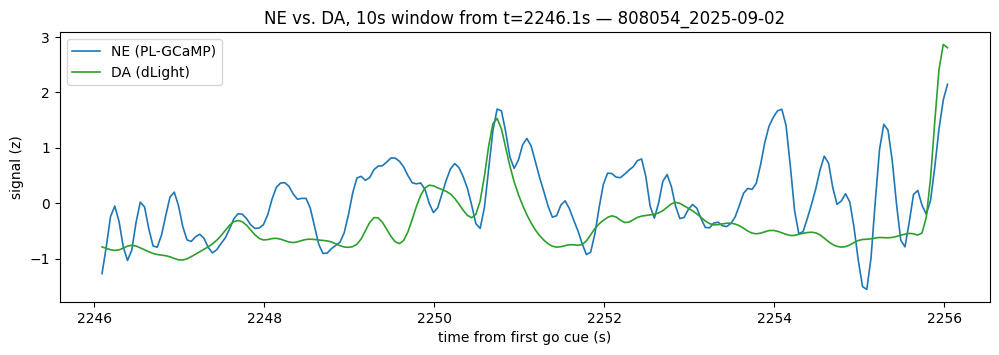

In [83]:
TRACE_WINDOW_DUR = 10.0  # seconds -- window length
TRACE_WINDOW_START = float(t_ne.min() + (t_ne.max() - t_ne.min()) / 2)  # default: mid-session


def plot_ne_da_window(t_start, duration=TRACE_WINDOW_DUR):
    t_end = t_start + duration
    m_ne = (t_ne >= t_start) & (t_ne <= t_end)
    m_da = (t_da >= t_start) & (t_da <= t_end)
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(t_ne[m_ne], ne_z[m_ne], color="#1f77b4", lw=1.2, label="NE (PL-GCaMP)")
    ax.plot(t_da[m_da], da_z[m_da], color="#2ca02c", lw=1.2, label="DA (dLight)")
    ax.set_xlabel("time from first go cue (s)")
    ax.set_ylabel("signal (z)")
    ax.set_title(f"NE vs. DA, {duration:.0f}s window from t={t_start:.1f}s — {nwb.session_id}")
    ax.legend()
    plt.show()


plot_ne_da_window(TRACE_WINDOW_START)

## NE↔DA cross-correlation

Session-wide lead/lag relationship between the two continuous traces, independent of onset
detection — resample both onto a common grid over their time overlap (same recipe
`fip_00_explore.ipynb` uses for motion energy × FIP), then `norm_xcorr`. **Positive lag = NE
leads DA**, chosen to match the sign convention used by the onset-lag distribution further
below (`da_onset - ne_onset`, positive when DA follows NE).

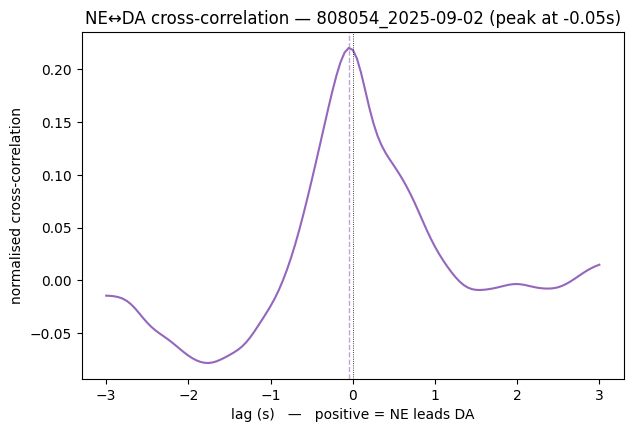

Peak cross-correlation at lag -0.05s (value=0.220)


In [84]:
FS_XC = 20    # Hz, common resampling grid
MAXLAG = 3.0  # s

xcorr_lo = max(t_ne.min(), t_da.min())
xcorr_hi = min(t_ne.max(), t_da.max())
xcorr_grid = np.arange(xcorr_lo, xcorr_hi, 1.0 / FS_XC)
ne_i = np.interp(xcorr_grid, t_ne, ne_z)
da_i = np.interp(xcorr_grid, t_da, da_z)

# b=ne_i -> positive lag means NE leads DA (see norm_xcorr's docstring for the sign convention).
xcorr_lags, xcorr = norm_xcorr(da_i, ne_i, fs=FS_XC, maxlag=MAXLAG)
peak_lag = xcorr_lags[int(np.argmax(xcorr))]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xcorr_lags, xcorr, color="#9467bd")
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.axvline(peak_lag, color="#9467bd", lw=1, ls="--", alpha=0.6)
ax.set_xlabel("lag (s)   —   positive = NE leads DA")
ax.set_ylabel("normalised cross-correlation")
ax.set_title(f"NE↔DA cross-correlation — {nwb.session_id} (peak at {peak_lag:+.2f}s)")
plt.show()

print(f"Peak cross-correlation at lag {peak_lag:+.2f}s (value={xcorr.max():.3f})")

## Onset detection and NE-only / NE+DA classification

Same `threshold_onsets` parameters already used for motion energy in `fip_00_explore.ipynb`
(`z_thresh=2.5`, `refractory=0.5`, `min_run=3`) — flagged there as an open "tune onsets" TODO;
unchanged here, not re-litigated. `WINDOW` (±0.5 s) is the coincidence window confirmed for
this analysis: an NE onset counts as NE+DA if any DA onset falls within it.

In [99]:
Z_THRESH = 1.0
REFRACTORY = 0.5
MIN_RUN = 10
WINDOW = 1  # seconds, NE<->DA coincidence window

ne_onsets = threshold_onsets(t_ne, ne, z_thresh=Z_THRESH, refractory=REFRACTORY, min_run=MIN_RUN)
da_onsets = threshold_onsets(t_da, da, z_thresh=Z_THRESH, refractory=REFRACTORY, min_run=MIN_RUN)
print(f"{len(ne_onsets)} NE onsets, {len(da_onsets)} DA onsets (z>{Z_THRESH})")

if len(da_onsets):
    ne_da_dists = np.abs(ne_onsets[:, None] - da_onsets[None, :])
    has_da = (ne_da_dists <= WINDOW).any(axis=1)
else:
    has_da = np.zeros(len(ne_onsets), dtype=bool)

ne_only_onsets = ne_onsets[~has_da]
ne_da_onsets = ne_onsets[has_da]

print(f"  {len(ne_only_onsets)} NE-only (no DA onset within ±{WINDOW}s)")
print(f"  {len(ne_da_onsets)} NE+DA (DA onset within ±{WINDOW}s)")

319 NE onsets, 344 DA onsets (z>1.0)
  224 NE-only (no DA onset within ±1s)
  95 NE+DA (DA onset within ±1s)


### QC — example onsets from each group

Sanity check before trusting the aggregate analyses below: NE-only examples should visibly lack
a DA co-transient; NE+DA examples should show one.

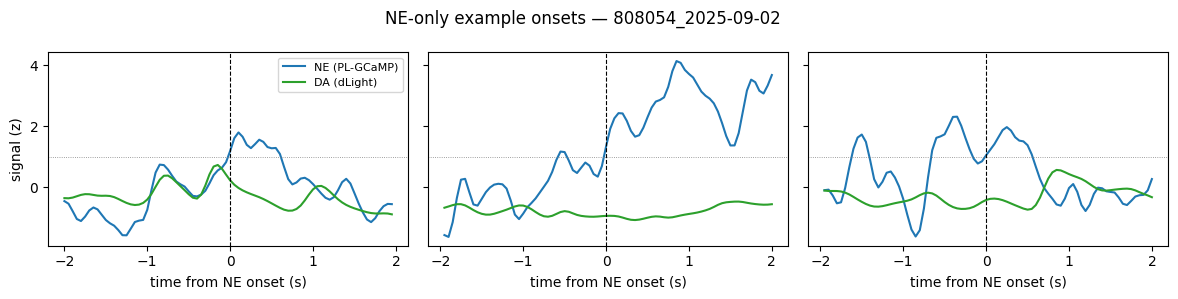

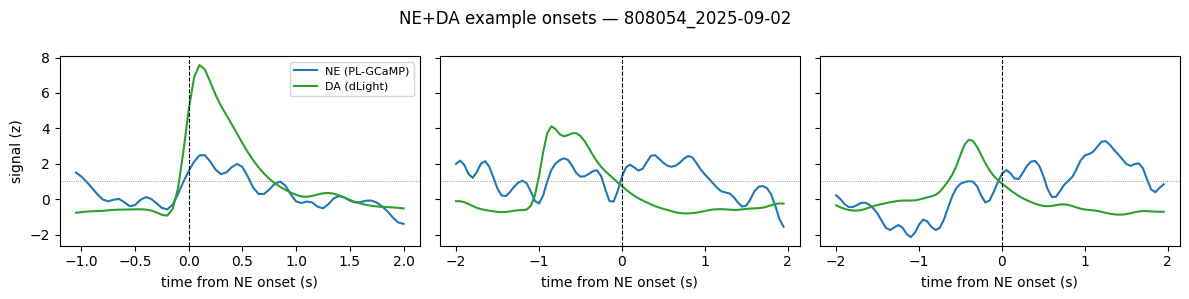

In [100]:
def plot_example_onsets(onset_times, title, n=3, window=2.0):
    n = min(n, len(onset_times))
    if n == 0:
        print(f"No examples for: {title}")
        return
    picks = onset_times[np.linspace(0, len(onset_times) - 1, n).astype(int)]
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, onset in zip(axes, picks):
        m_ne = (t_ne >= onset - window) & (t_ne <= onset + window)
        m_da = (t_da >= onset - window) & (t_da <= onset + window)
        ax.plot(t_ne[m_ne] - onset, ne_z[m_ne], color="#1f77b4", label="NE (PL-GCaMP)")
        ax.plot(t_da[m_da] - onset, da_z[m_da], color="#2ca02c", label="DA (dLight)")
        ax.axvline(0, color="k", lw=0.8, ls="--")
        ax.axhline(Z_THRESH, color="gray", lw=0.6, ls=":")
        ax.set_xlabel("time from NE onset (s)")
    axes[0].set_ylabel("signal (z)")
    axes[0].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_example_onsets(ne_only_onsets, f"NE-only example onsets — {nwb.session_id}")
plot_example_onsets(ne_da_onsets, f"NE+DA example onsets — {nwb.session_id}")

## Quantitative NE–DA relationship analyses

The onset-coincidence split above is a hard cutoff through what might be a continuum. Four
analyses characterize the relationship itself, beyond that binary split.

### DA peak distribution around NE onsets

For *every* NE onset (not just the NE+DA subset), the max DA (z) within ±`WINDOW` of it.
Bimodal = the NE-only/NE+DA split is a real dichotomy; smeared/continuous = the split is
cutting through a continuum and should be caveated as such.

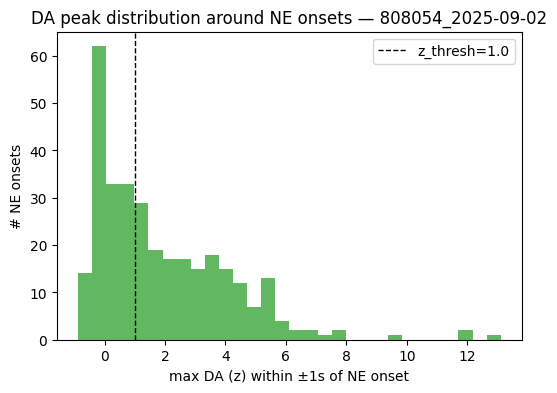

In [101]:
def peak_in_window(t, z, centers, window):
    """max(z) within [center-window, center+window] for each center; NaN if no samples."""
    out = np.full(len(centers), np.nan)
    for i, c in enumerate(centers):
        m = (t >= c - window) & (t <= c + window)
        if m.any():
            out[i] = np.nanmax(z[m])
    return out


da_peak_z = peak_in_window(t_da, da_z, ne_onsets, WINDOW)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(da_peak_z, bins=30, color="#2ca02c", alpha=0.75)
ax.axvline(Z_THRESH, color="k", lw=1, ls="--", label=f"z_thresh={Z_THRESH}")
ax.set_xlabel(f"max DA (z) within ±{WINDOW}s of NE onset")
ax.set_ylabel("# NE onsets")
ax.set_title(f"DA peak distribution around NE onsets — {nwb.session_id}")
ax.legend()
plt.show()

### Shuffle control for the coincidence rate

Circular-shift the DA onset train by a random offset (wrapped within the session's time range),
~1000 times, recomputing the NE+DA coincidence rate each time. Compares the observed rate
against this null to ask whether the overlap is more than each signal's own baseline event rate
would produce by chance.

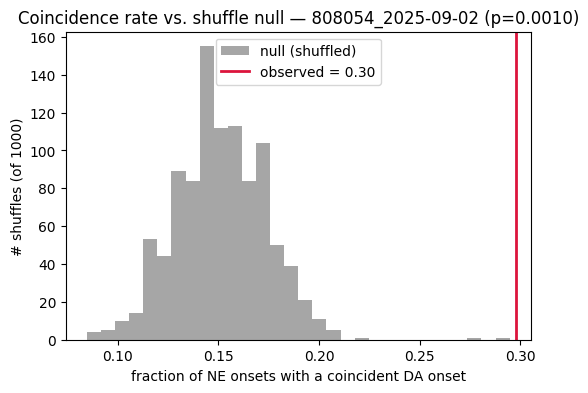

Observed: 0.298 | shuffle null mean: 0.151 | empirical p-value: 0.0010


In [102]:
N_SHUFFLES = 1000
rng = np.random.default_rng(0)

t_min = float(min(t_ne.min(), t_da.min()))
t_max = float(max(t_ne.max(), t_da.max()))
session_dur = t_max - t_min


def coincidence_rate(ne_t, da_t, window):
    if len(da_t) == 0 or len(ne_t) == 0:
        return 0.0
    d = np.abs(ne_t[:, None] - da_t[None, :])
    return (d <= window).any(axis=1).mean()


observed_rate = coincidence_rate(ne_onsets, da_onsets, WINDOW)

null_rates = np.empty(N_SHUFFLES)
for i in range(N_SHUFFLES):
    shift = rng.uniform(0, session_dur)
    da_shifted = t_min + (da_onsets - t_min + shift) % session_dur
    null_rates[i] = coincidence_rate(ne_onsets, da_shifted, WINDOW)

p_value = (np.sum(null_rates >= observed_rate) + 1) / (N_SHUFFLES + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(null_rates, bins=30, color="gray", alpha=0.7, label="null (shuffled)")
ax.axvline(observed_rate, color="crimson", lw=2, label=f"observed = {observed_rate:.2f}")
ax.set_xlabel("fraction of NE onsets with a coincident DA onset")
ax.set_ylabel(f"# shuffles (of {N_SHUFFLES})")
ax.set_title(f"Coincidence rate vs. shuffle null — {nwb.session_id} (p={p_value:.4f})")
ax.legend()
plt.show()

print(f"Observed: {observed_rate:.3f} | shuffle null mean: {null_rates.mean():.3f} "
      f"| empirical p-value: {p_value:.4f}")

### Lag distribution for coincident pairs

For each NE+DA onset, the nearest DA onset's time minus the NE onset's time — does DA tend to
lead, lag, or center on NE?

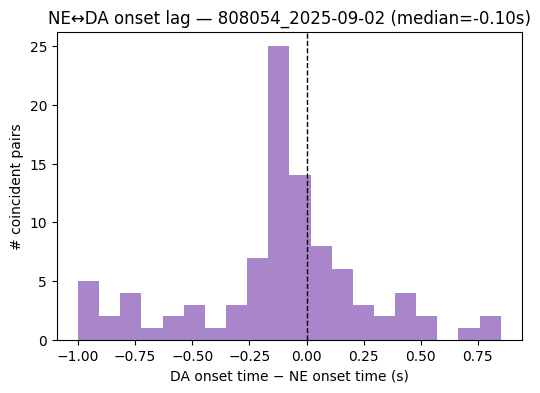

median lag: -0.100s | mean lag: -0.118s


In [103]:
if len(ne_da_onsets) and len(da_onsets):
    lags = np.array([
        da_onsets[np.argmin(np.abs(da_onsets - onset))] - onset
        for onset in ne_da_onsets
    ])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(lags, bins=20, color="#9467bd", alpha=0.8)
    ax.axvline(0, color="k", lw=1, ls="--")
    ax.set_xlabel("DA onset time − NE onset time (s)")
    ax.set_ylabel("# coincident pairs")
    ax.set_title(f"NE↔DA onset lag — {nwb.session_id} (median={np.median(lags):+.2f}s)")
    plt.show()
    print(f"median lag: {np.median(lags):+.3f}s | mean lag: {lags.mean():+.3f}s")
else:
    print("No coincident NE+DA pairs to compute lag for.")

### Amplitude correlation

For coincident pairs, NE peak amplitude (max NE z-score shortly after each NE onset) vs. DA
peak amplitude (`da_peak_z`, computed above, restricted to the NE+DA subset) — does a bigger NE
transient come with a bigger concurrent DA transient?

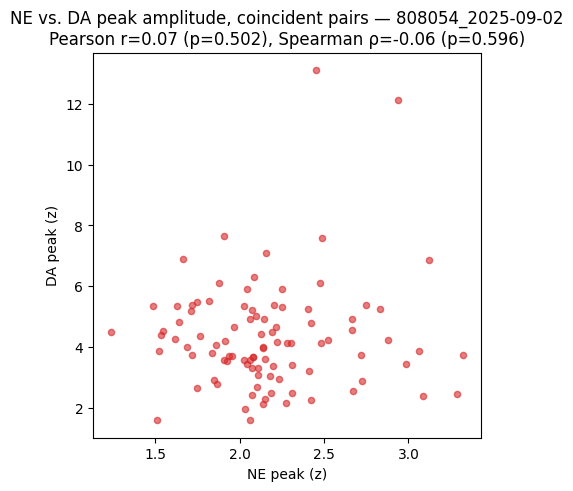

In [104]:
ne_peak_z = peak_in_window(t_ne, ne_z, ne_da_onsets, WINDOW)
da_peak_z_coincident = da_peak_z[has_da]

valid = np.isfinite(ne_peak_z) & np.isfinite(da_peak_z_coincident)
if valid.sum() >= 3:
    r_pearson, p_pearson = stats.pearsonr(ne_peak_z[valid], da_peak_z_coincident[valid])
    r_spearman, p_spearman = stats.spearmanr(ne_peak_z[valid], da_peak_z_coincident[valid])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(ne_peak_z[valid], da_peak_z_coincident[valid], s=20, alpha=0.6, color="#d62728")
    ax.set_xlabel("NE peak (z)")
    ax.set_ylabel("DA peak (z)")
    ax.set_title(f"NE vs. DA peak amplitude, coincident pairs — {nwb.session_id}\n"
                f"Pearson r={r_pearson:.2f} (p={p_pearson:.3f}), "
                f"Spearman ρ={r_spearman:.2f} (p={p_spearman:.3f})")
    plt.show()
else:
    print(f"Only {int(valid.sum())} valid coincident pairs -- too few for a correlation.")

## Main figure — motion energy aligned to NE-only vs. NE+DA onsets

`peri_event` on z-scored ME, `censor=False` (movement onsets are closely spaced — same
rationale documented in `fip_00_explore.ipynb`'s onset-alignment cells), one trace per group.

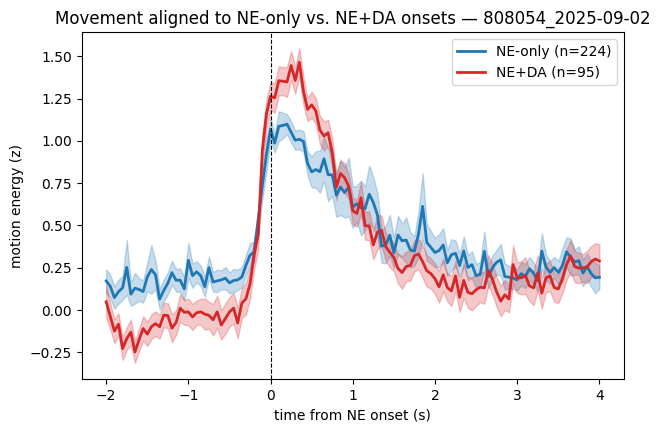

In [105]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for onsets, label, color in [(ne_only_onsets, f"NE-only (n={len(ne_only_onsets)})", "#1f77b4"),
                             (ne_da_onsets, f"NE+DA (n={len(ne_da_onsets)})", "#d62728")]:
    if len(onsets) == 0:
        print(f"No onsets for {label}; skipping.")
        continue
    etr = peri_event(t_me_z, me_z, onsets, t_before=2.0, t_after=4.0, censor=False)
    if etr is None or etr.empty:
        print(f"No ETR for {label}; skipping.")
        continue
    g = etr.groupby("time")["data"]
    mean, sem = g.mean(), g.sem()
    ax.plot(mean.index, mean.values, color=color, lw=2, label=label)
    ax.fill_between(mean.index, (mean - sem).values, (mean + sem).values, color=color, alpha=0.25)
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("time from NE onset (s)")
ax.set_ylabel("motion energy (z)")
ax.set_title(f"Movement aligned to NE-only vs. NE+DA onsets — {nwb.session_id}")
ax.legend()
plt.show()

## Z-threshold sensitivity sweep

Every analysis above runs at a single `Z_THRESH` (set in the onset-detection cell above).
How much of the NE-only/NE+DA story depends on that specific choice? This section reruns
onset detection and all four quantitative analyses -- shuffle control, lag distribution,
peak-amplitude correlation, and the ME-alignment comparison -- across a sweep of detection
thresholds from z=1 to z=3, one four-panel summary figure per threshold.

This is a robustness check, not a new claim: `REFRACTORY`, `MIN_RUN`, and the NE<->DA
coincidence `WINDOW` are held fixed at their values above, only `z_thresh` varies. The
shuffle control here uses fewer resamples (`N_SHUFFLES_SWEEP=500` vs. `N_SHUFFLES=1000`
above) since the whole pipeline reruns once per sweep point.

In [ ]:
N_SHUFFLES_SWEEP = 500
Z_SWEEP = np.arange(1.0, 3.01, 0.5)  # 1.0, 1.5, 2.0, 2.5, 3.0


def analyze_at_zthresh(z_thresh, *, refractory=REFRACTORY, min_run=MIN_RUN, window=WINDOW,
                        n_shuffles=N_SHUFFLES_SWEEP, rng=None):
    """Rerun onset detection, classification, and the four downstream analyses at one z_thresh.

    Reuses `threshold_onsets`, `peak_in_window`, `peri_event`, and `coincidence_rate`
    exactly as the main analysis above calls them -- only the detection threshold
    changes. Results are returned rather than assigned at module level, so the sweep
    can't clobber the main analysis's `ne_onsets`/`lags`/etc. variables.

    Parameters
    ----------
    z_thresh : float
        Onset-detection threshold (z-score), passed to `threshold_onsets` for both NE
        and DA.
    refractory, min_run, window : float
        Held fixed across the sweep at the notebook's main-analysis values
        (`REFRACTORY`, `MIN_RUN`, `WINDOW`).
    n_shuffles : int
        Shuffle count for the coincidence-rate null.
    rng : numpy.random.Generator, optional
        Defaults to a fresh `default_rng(0)` per call, so every threshold draws the same
        shuffle sequence and differences across the sweep come only from `z_thresh`.

    Returns
    -------
    dict
        z_thresh, ne_onsets, da_onsets, ne_only_onsets, ne_da_onsets, observed_rate,
        null_rates, p_value, lags, ne_peak_z, da_peak_z_coincident, r_pearson,
        p_pearson, r_spearman, p_spearman, etr_ne_only, etr_ne_da.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    ne_onsets_z = threshold_onsets(t_ne, ne, z_thresh=z_thresh, refractory=refractory, min_run=min_run)
    da_onsets_z = threshold_onsets(t_da, da, z_thresh=z_thresh, refractory=refractory, min_run=min_run)

    if len(da_onsets_z):
        d = np.abs(ne_onsets_z[:, None] - da_onsets_z[None, :])
        has_da_z = (d <= window).any(axis=1)
    else:
        has_da_z = np.zeros(len(ne_onsets_z), dtype=bool)
    ne_only_z = ne_onsets_z[~has_da_z]
    ne_da_z = ne_onsets_z[has_da_z]

    # Shuffle control (same circular-shift recipe as the main analysis's coincidence_rate cell)
    observed_rate = coincidence_rate(ne_onsets_z, da_onsets_z, window)
    null_rates = np.empty(n_shuffles)
    for i in range(n_shuffles):
        shift = rng.uniform(0, session_dur)
        da_shifted = t_min + (da_onsets_z - t_min + shift) % session_dur
        null_rates[i] = coincidence_rate(ne_onsets_z, da_shifted, window)
    p_value = (np.sum(null_rates >= observed_rate) + 1) / (n_shuffles + 1)

    # Lag distribution for coincident pairs
    if len(ne_da_z) and len(da_onsets_z):
        lags = np.array([
            da_onsets_z[np.argmin(np.abs(da_onsets_z - onset))] - onset
            for onset in ne_da_z
        ])
    else:
        lags = np.array([])

    # Peak-amplitude correlation for coincident pairs
    da_peak_z_all = peak_in_window(t_da, da_z, ne_onsets_z, window)
    ne_peak_z_pts = peak_in_window(t_ne, ne_z, ne_da_z, window)
    da_peak_z_coincident = da_peak_z_all[has_da_z]
    valid = np.isfinite(ne_peak_z_pts) & np.isfinite(da_peak_z_coincident)
    if valid.sum() >= 3:
        r_pearson, p_pearson = stats.pearsonr(ne_peak_z_pts[valid], da_peak_z_coincident[valid])
        r_spearman, p_spearman = stats.spearmanr(ne_peak_z_pts[valid], da_peak_z_coincident[valid])
    else:
        r_pearson = p_pearson = r_spearman = p_spearman = np.nan

    # ME alignment, one ETR per group
    etr_ne_only = (peri_event(t_me_z, me_z, ne_only_z, t_before=2.0, t_after=4.0, censor=False)
                   if len(ne_only_z) else None)
    etr_ne_da = (peri_event(t_me_z, me_z, ne_da_z, t_before=2.0, t_after=4.0, censor=False)
                 if len(ne_da_z) else None)

    return dict(
        z_thresh=z_thresh, ne_onsets=ne_onsets_z, da_onsets=da_onsets_z,
        ne_only_onsets=ne_only_z, ne_da_onsets=ne_da_z,
        observed_rate=observed_rate, null_rates=null_rates, p_value=p_value, lags=lags,
        ne_peak_z=ne_peak_z_pts[valid], da_peak_z_coincident=da_peak_z_coincident[valid],
        r_pearson=r_pearson, p_pearson=p_pearson, r_spearman=r_spearman, p_spearman=p_spearman,
        etr_ne_only=etr_ne_only, etr_ne_da=etr_ne_da,
    )

In [ ]:
def plot_zthresh_summary(res):
    """Four-panel summary figure for one z_thresh: shuffle control, lag distribution,
    peak-amplitude correlation, and ME alignment -- the same four analyses run above at
    the notebook's main `Z_THRESH`, replicated at `res["z_thresh"]`.

    Parameters
    ----------
    res : dict
        Output of `analyze_at_zthresh`.
    """
    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

    ax = axes[0, 0]
    ax.hist(res["null_rates"], bins=30, color="gray", alpha=0.7, label="null (shuffled)")
    ax.axvline(res["observed_rate"], color="crimson", lw=2,
               label=f"observed = {res['observed_rate']:.2f}")
    ax.set_xlabel("fraction of NE onsets with coincident DA onset")
    ax.set_ylabel("# shuffles")
    ax.set_title(f"Coincidence vs. shuffle null (p={res['p_value']:.4f})")
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    if len(res["lags"]):
        ax.hist(res["lags"], bins=20, color="#9467bd", alpha=0.8)
        ax.axvline(0, color="k", lw=1, ls="--")
        ax.set_title(f"NE↔DA onset lag (median={np.median(res['lags']):+.2f}s)")
    else:
        ax.text(0.5, 0.5, "no coincident pairs", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("NE↔DA onset lag")
    ax.set_xlabel("DA onset time − NE onset time (s)")
    ax.set_ylabel("# coincident pairs")

    ax = axes[1, 0]
    if len(res["ne_peak_z"]) >= 3:
        ax.scatter(res["ne_peak_z"], res["da_peak_z_coincident"], s=18, alpha=0.6, color="#d62728")
        ax.set_title(f"NE vs. DA peak amplitude\n"
                    f"Pearson r={res['r_pearson']:.2f} (p={res['p_pearson']:.3f})")
    else:
        ax.text(0.5, 0.5, "too few coincident pairs", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("NE vs. DA peak amplitude")
    ax.set_xlabel("NE peak (z)")
    ax.set_ylabel("DA peak (z)")

    ax = axes[1, 1]
    for etr, label, color in [
        (res["etr_ne_only"], f"NE-only (n={len(res['ne_only_onsets'])})", "#1f77b4"),
        (res["etr_ne_da"], f"NE+DA (n={len(res['ne_da_onsets'])})", "#d62728"),
    ]:
        if etr is None or etr.empty:
            continue
        g = etr.groupby("time")["data"]
        mean, sem = g.mean(), g.sem()
        ax.plot(mean.index, mean.values, color=color, lw=2, label=label)
        ax.fill_between(mean.index, (mean - sem).values, (mean + sem).values, color=color, alpha=0.25)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("time from NE onset (s)")
    ax.set_ylabel("motion energy (z)")
    ax.set_title("ME aligned to NE-only vs. NE+DA")
    ax.legend(fontsize=8)

    fig.suptitle(f"z_thresh = {res['z_thresh']:.1f} — {nwb.session_id}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
sweep_rows = []
for z in Z_SWEEP:
    res = analyze_at_zthresh(float(z))
    plot_zthresh_summary(res)
    sweep_rows.append(dict(
        z_thresh=res["z_thresh"],
        n_ne=len(res["ne_onsets"]), n_da=len(res["da_onsets"]),
        n_ne_only=len(res["ne_only_onsets"]), n_ne_da=len(res["ne_da_onsets"]),
        observed_rate=res["observed_rate"], p_value=res["p_value"],
        median_lag=np.median(res["lags"]) if len(res["lags"]) else np.nan,
        r_pearson=res["r_pearson"], p_pearson=res["p_pearson"],
    ))

sweep_summary = pd.DataFrame(sweep_rows)
print(sweep_summary.to_string(index=False))